# Using ANNs to Predict Used Car Prices

### Setup and Library Imports

In [1]:
!python -m pip uninstall numpy --yes # There's a problem with my pytorch installation
!python -m pip install "numpy<2"

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl (20.3 MB)

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [4]:
torch.manual_seed(4210)

### Creating a Custom Dataset

Since we're embedding our categorical features (i.e. brand, model, fuel type, transmission type), we need to create fields in our Dataset class that represent the amount of unique categories they have. This makes it easier to create our embeddings later on.

In [5]:
class CSVDataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file)
        self.num_brands = self.data['brand'].nunique()
        self.num_models = self.data['model'].nunique()
        self.num_fuel_types = self.data['fuel_type'].nunique()
        self.num_transmissions = self.data['transmission_type'].nunique()
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        categorical_values = torch.tensor(row[['brand','model','fuel_type','transmission_type']].values.astype(np.int32))
        numerical_values = torch.tensor(row[['model_year', 'mileage', 'clean_title']].values.astype(np.float32))
        target = torch.tensor(row['log_price'], dtype=torch.float32)

        return categorical_values, numerical_values, target

### Instantiating Dataset, Loading our Data

The `.csv` file we will use was generated using a script called `cleandata-pytorch.py`. It functions similar to the script used for the other experiments, but with a few differences:
- It encodes more than just the brands: models, fuel type, and transmission type are also encoded
- Our numerical features (i.e. mileage, model year) are normalized using `sklearn`'s `StandardScaler()`
- A new column, `log_price`, is created; this represents the natural log of the values in the `price` column

In [6]:
csv_file = 'pytorch_used_cars.csv'
dataset = CSVDataset(csv_file)

In order to keep things consistent with our testing methodology, we will use a 90%/10% train-test split.

In [7]:
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size
 
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64)

### Defining our Neural Network

We will use a 3-layer Artificial Neural Network. Each layer contains 128 neurons.

#### Why are we embedding our categorical features?
Since input data for a neural network needs to be consistent across datatypes, we run into an issue with our data: we have both categorical values and numerical values. The problem with label encoding our categorical values is that the label implies ordinality; in other words, it suggests an order among all the labels. This doesn't make sense with, for example, our brands feature, because how is Ford > Honda?

One-hot encoding would work, but I didn't want to run the risk of having our dataset grow too big and sparse with the number of dummy columns, especially since some features (brand and model) have many unique values. So, I came across another technique: embedding. Embedding compresses each categorical input into a vector of real numbers, each representing a certain characteristic of that category. This allows the machine learning model to discover the relationships between each category value.

In total, our network accepts a vector with 51 input values: 8 dimensions for brand embedding, 32 dimensions for model embedding, 4 dimensions for fuel type embedding, 4 dimensions for transmission type embedding, and 3 dimensions for mileage, model_year, clean_title.

In [8]:
class NeuralNetwork(nn.Module):
    def __init__(self, num_brands, num_models, num_fuel_types, num_transmission_types):
        super(NeuralNetwork, self).__init__()
        input_dim = 51
        self.layer_1 = nn.Linear(input_dim, 128)
        self.layer_2 = nn.Linear(128, 128)
        self.layer_3 = nn.Linear(128, 128)
        self.layer_out = nn.Linear(128, 1)
        self.brand_embedding = nn.Embedding(num_brands,8)
        self.model_embedding = nn.Embedding(num_models,32)
        self.fuel_type_embedding = nn.Embedding(num_fuel_types,4)
        self.transmission_embedding = nn.Embedding(num_transmission_types,4)

    def forward(self, categorical_inputs, numerical_inputs):
        brand_embedded = self.brand_embedding(categorical_inputs[:, 0])
        model_embedded = self.model_embedding(categorical_inputs[:, 1])
        fuel_embedded = self.fuel_type_embedding(categorical_inputs[:, 2])
        transmission_embedded = self.transmission_embedding(categorical_inputs[:, 3])
        x = torch.cat([brand_embedded, model_embedded, fuel_embedded,
                       transmission_embedded, numerical_inputs], dim=1)
        
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = F.relu(self.layer_3(x))
        x = self.layer_out(x)
        return x.squeeze(1)

### Instantiating our Model, Criterion, and Optimizer

In [9]:
model = NeuralNetwork(num_brands=dataset.num_brands,
                      num_models=dataset.num_models,
                      num_fuel_types=dataset.num_fuel_types,
                      num_transmission_types=dataset.num_transmissions)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training our Model

In [10]:
num_epochs = 10

losses = []

for epoch in range(num_epochs):
    model.train()
    for categorical_inputs, numerical_inputs, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = model(categorical_inputs, numerical_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    losses.append(loss.item())
    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')

Epoch 1/10, Loss: 1.8410
Epoch 2/10, Loss: 1.0943
Epoch 3/10, Loss: 1.0703
Epoch 4/10, Loss: 1.3750
Epoch 5/10, Loss: 0.3615
Epoch 6/10, Loss: 0.5374
Epoch 7/10, Loss: 0.2541
Epoch 8/10, Loss: 0.2859
Epoch 9/10, Loss: 0.1552
Epoch 10/10, Loss: 0.1453


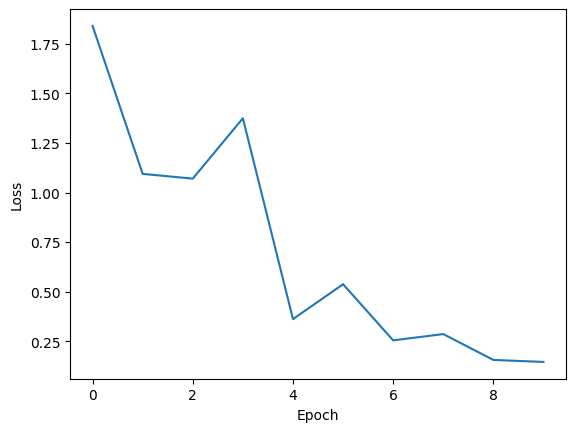

In [11]:
plt.plot([i for i in range(10)], losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Evaluating our Model

In [12]:
from sklearn.metrics import root_mean_squared_error, r2_score

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for categorical_inputs, numerical_inputs, labels in train_dataloader:
        outputs = model(categorical_inputs, numerical_inputs)
        y_true.append(labels)
        y_pred.append(outputs)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

y_true_price = np.exp(y_true)
y_pred_price = np.exp(y_pred)

rmse = root_mean_squared_error(y_true_price, y_pred_price)
r2 = r2_score(y_true_price, y_pred_price)

print(f"Root mean square error: {rmse:.2f}")
print(f"R^2: {r2:.4f}")

Root mean square error: 69304.94
R^2: 0.2662
